# Drift Chamber Garfield++ Sim Data Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
import pandas as pd
import random

p = 3 * 760 # [Torr]

xpos = np.array([0, -0.3, 0, 0.3, -0.3, 0.3, -0.3, 0, 0.3])
ypos = np.array([0, 0.3, 0.3, 0.3, 0, 0, -0.3, -0.3, -0.3])

## Comparison of Gases

In [4]:
def ran_colour(): return "#{:06x}".format(random.randint(0, 0xFFFFFF))

class Gas:
    def __init__(self, name, nick, percent, num_drift=-1, num_driftB=-1):
        self.name = name
        self.nick = nick
        self.percent = percent
        self.num_drift = num_drift
        self.num_driftB = num_driftB

In [5]:
Ne_driftlines = np.mean( np.array([62, 61, 62, 61, 63, 87, 86, 46]) )
Ne_driftlines_Bfield = np.mean( np.array([54, 43, 48, 49, 49, 46, 63, 35]) )

Ar93_driftlines = np.mean( np.array([311, 289, 283, 249, 416, 390, 330, 331, 226]) )
Ar93_driftlines_Bfield = np.mean( np.array([367, 461, 370, 378, 454, 338, 347, 374]) )

Ar80_driftlines = np.mean( np.array([173, 85, 113, 104, 126, 85, 167, 113]) )
Ar80_driftlines_Bfield = np.mean( np.array([70, 101, 193, 99, 89, 115, 102, 68]) )

He90_ethane = np.mean( np.array([92, 48, 48, 75, 100, 48, 50, 53, 50]) )
He90_ethane_B = np.mean( np.array([53, 49, 43, 59, 54, 39, 52, 75, 48]) )

He93_driftlines = np.mean( np.array([34, 43, 54, 49, 55, 45, 44, 55]) )
He93_driftlines_B = np.mean( np.array([48, 71, 41, 34, 46, 71, 39, 41]) )

He_50_c2h6_50_drift = np.mean( np.array([163, 166, 202, 226, 153, 202, 180]) )
He_50_c2h6_50_driftB = np.mean( np.array([214, 260, 222, 158, 203, 158, 179]) )

He_78_drift = np.mean( np.array([158, 89, 115, 195, 80, 77, 97, 88]) )
He_78_driftB = np.mean( np.array([98, 125, 98, 94, 90, 116, 118, 92]) )

Ar90_methane = np.mean( np.array([244, 192, 199, 311]) )
Ar90_methaneB = np.mean( np.array([262, 347, 262, 488]) )

In [6]:
Ne_gas = Gas("Ne_90_CO2_10_N2_5_with_mg", "Ne–CO$_2$–N$_2$", "(90/10/5)", Ne_driftlines, Ne_driftlines_Bfield)
Ar_93_gas = Gas("ar_93_co2_7_3bar", "Ar–CO$_2$", "(93/7)", Ar93_driftlines, Ar93_driftlines_Bfield)
Ar_80_gas = Gas("ar_80_co2_20_0T", "Ar–CO$_2$", "(80/20)", Ar80_driftlines, Ar80_driftlines_Bfield)
He_90_ethane = Gas("he_90_c2h6_10", "He–C$_2$H$_6$", "(90/10)", He90_ethane, He90_ethane_B)
He_93_gas = Gas("he_94_c3h8_6", "He–C$_3$H$_8$", "(93.8/6.2)", He93_driftlines, He93_driftlines_B)
He_50_gas = Gas("he_50_c2h6_50", "He–C$_2$H$_6$", "(50/50)", He_50_c2h6_50_drift, He_50_c2h6_50_driftB)
He_78_gas = Gas("he_78_co2_15_c4h10_7", "He–CO$_2$–C$_4$H$_{10}$", "(78/15/7)", He_78_drift, He_78_driftB)
Ar_90_gas = Gas("ar_90_ch4_10", "Ar–CH$_4$", "(90/10)", Ar90_methane, Ar90_methaneB)

gases = [Ne_gas, Ar_93_gas, Ar_80_gas, He_90_ethane, He_93_gas, He_50_gas, He_78_gas, Ar_90_gas]

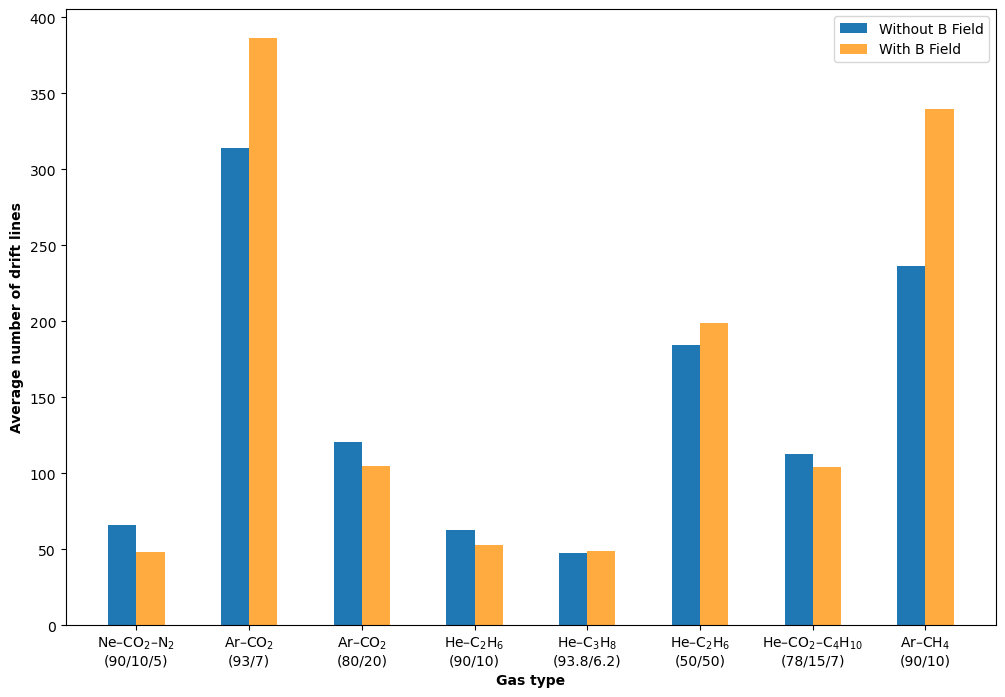

In [7]:
barWidth = 0.25
fig = plt.subplots(figsize =(12, 8)) 

noB_data = []
B_data = []
nicks = []

for gas in gases:
    if gas.num_drift == -1: continue
    noB_data.append(gas.num_drift)
    B_data.append(gas.num_driftB)
    nicks.append(f'{gas.nick}\n{gas.percent}')

br1 = np.arange(len(B_data)) 
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2] 

plt.bar(br1, noB_data, label='Without B Field', width=barWidth) 
plt.bar(br2, B_data, color="#ffab40", width=barWidth, label='With B Field') 

plt.xlabel('Gas type', fontweight='bold') 
plt.ylabel('Average number of drift lines', fontweight='bold') 
plt.xticks([r + barWidth/2 for r in range(len(B_data))], nicks)
plt.legend()

In [8]:
dfs = []
dfs_B = []

for gas in gases:
    df = pd.read_csv(f'csv/gas/{gas.name}.csv')
    df_B = pd.read_csv(f'csv/gas/{gas.name}_B.csv')

    df['Velocity'] = df['Distance'] / df['Time']
    df_B['Velocity'] = df_B['Distance'] / df_B['Time']

    df['E/p'] = df['EField'] / p
    df_B['E/p'] = df_B['EField'] / p
    
    dfs.append(df)
    dfs_B.append(df_B)

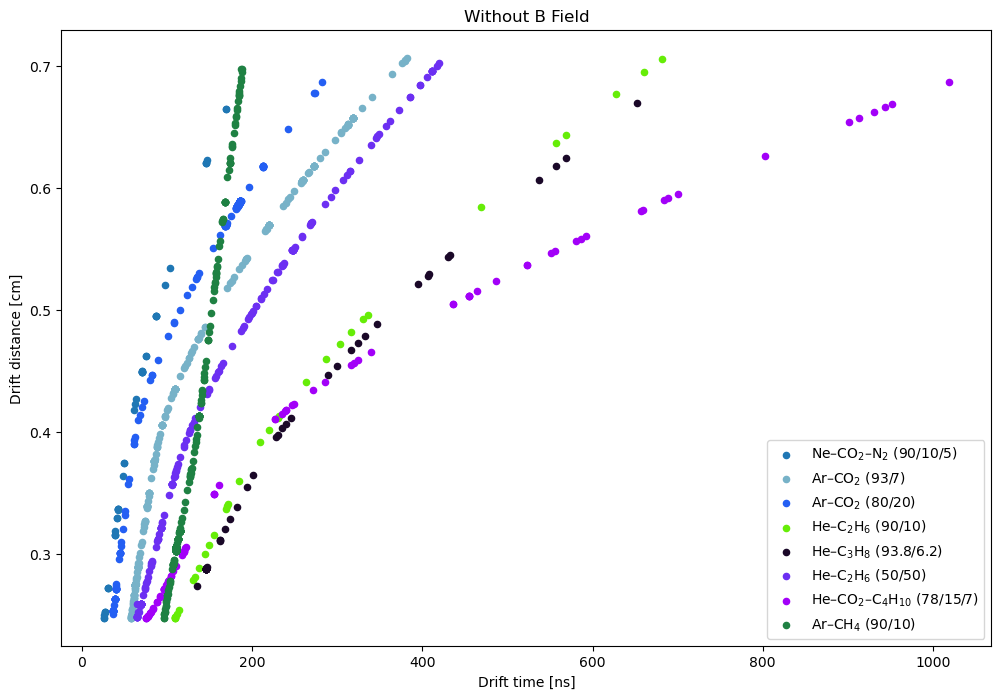

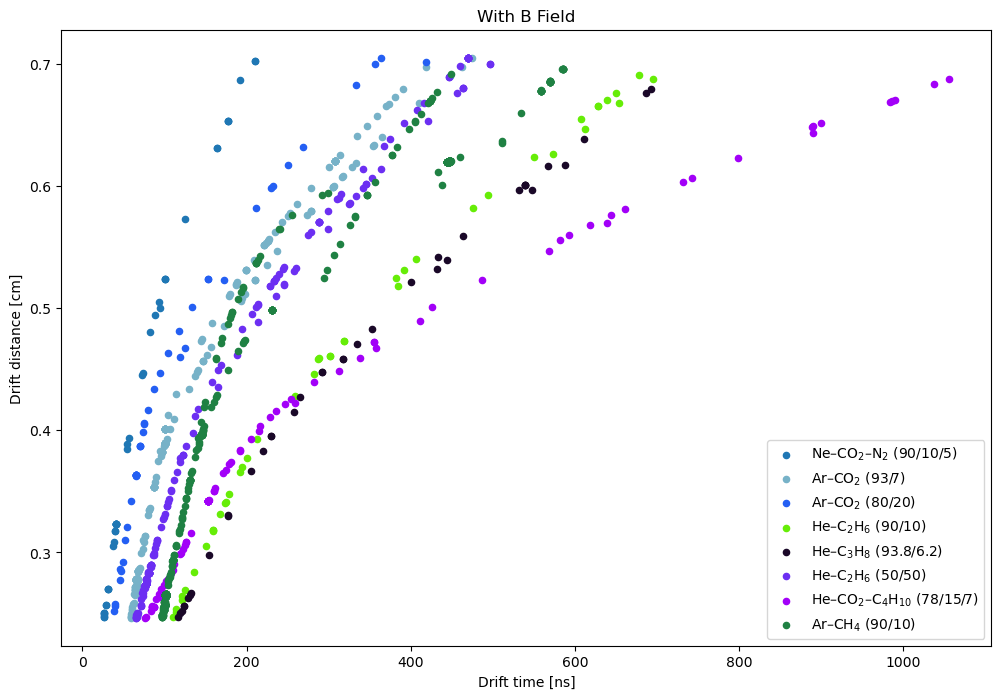

In [9]:
ax = dfs[0].plot(kind='scatter', x='Time', y='Distance', xlabel="Drift time [ns]", figsize =(12, 8), \
                 ylabel="Drift distance [cm]", label=f'{gases[0].nick} {gases[0].percent}', title="Without B Field")

ax_B = dfs_B[0].plot(kind='scatter', y='Distance', x='Time', xlabel="Drift time [ns]", figsize =(12, 8), \
                     ylabel="Drift distance [cm]", label=f'{gases[0].nick} {gases[0].percent}', title="With B Field")

for i in range(1, len(dfs)):
    ran_hex = ran_colour()
    dfs[i].plot(kind='scatter', y='Distance', x='Time', xlabel="Drift time [ns]", \
                ylabel="Drift distance [cm]", label=f'{gases[i].nick} {gases[i].percent}', ax=ax, color=ran_hex)
    
    dfs_B[i].plot(kind='scatter', y='Distance', x='Time', xlabel="Drift time [ns]", \
                ylabel="Drift distance [cm]", label=f'{gases[i].nick} {gases[i].percent}', ax=ax_B, color=ran_hex)

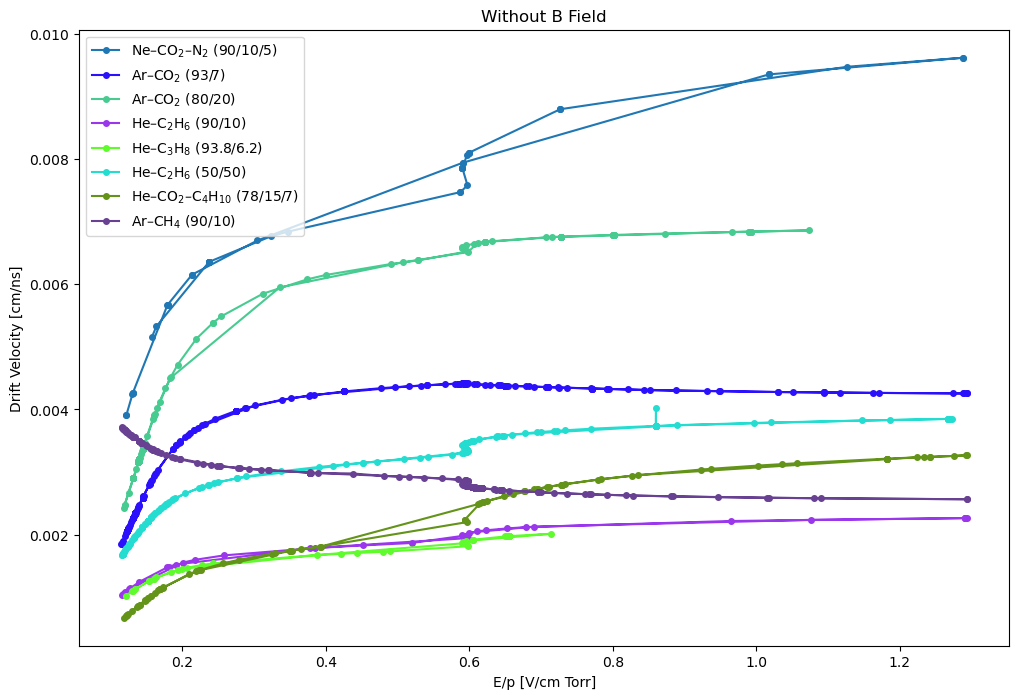

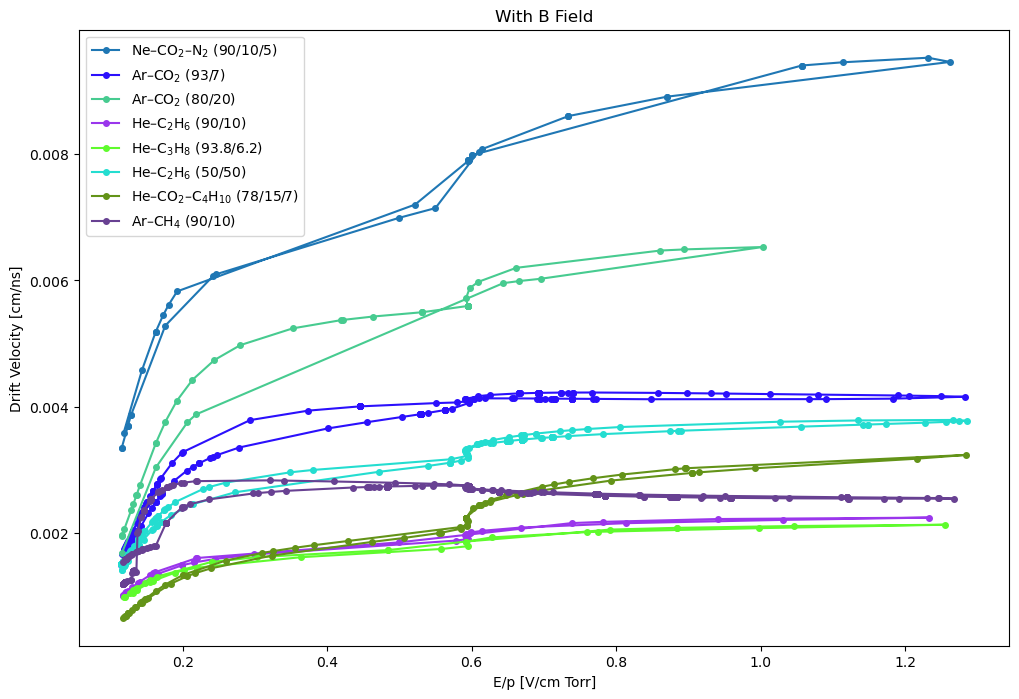

In [10]:
# E is taken as the point of the track where the drift  begins

ax2 = dfs[0].plot(x='E/p', y='Velocity', ylabel="Drift Velocity [cm/ns]", marker='o', ms=4, figsize =(12, 8), \
                 xlabel="E/p [V/cm Torr]", label=f'{gases[0].nick} {gases[0].percent}', title="Without B Field")

ax2_B = dfs_B[0].plot(x='E/p', y='Velocity', ylabel="Drift Velocity [cm/ns]", marker='o', ms=4, figsize =(12, 8), \
                 xlabel="E/p [V/cm Torr]", label=f'{gases[0].nick} {gases[0].percent}', title="With B Field")

for i in range(1, len(dfs)):
    ran_hex = ran_colour()
    dfs[i].plot(x='E/p', y='Velocity', ylabel="Drift Velocity [cm/ns]", marker='o', ms=4, \
                 xlabel="E/p [V/cm Torr]", label=f'{gases[i].nick} {gases[i].percent}', ax=ax2, color=ran_hex)
    
    dfs_B[i].plot(x='E/p', y='Velocity', ylabel="Drift Velocity [cm/ns]", marker='o', ms=4, \
                 xlabel="E/p [V/cm Torr]", label=f'{gases[i].nick} {gases[i].percent}', ax=ax2_B, color=ran_hex)

## Random Track Data

In [12]:
#track_num, theta, start_x, start_y, drift_times, line_start_x, line_start_y, num_driftlines

# csv of data of 1000 ran gen tracks in gas Ar-CO2 (93/7)
Ar_CO2_df = pd.read_csv(f'csv/rantrack/ar_co2_93l7_rantrack.csv')
Ar_CO2_df['drift_times_split'] = Ar_CO2_df['drift_times'].str.split('|')
Ar_CO2_df['line_start_x_split'] = Ar_CO2_df['line_start_x'].str.split('|')
Ar_CO2_df['line_start_y_split'] = Ar_CO2_df['line_start_y'].str.split('|')
Ar_CO2_df = Ar_CO2_df.drop(columns=['drift_times', 'line_start_x', 'line_start_y'])
Ar_CO2_str = "Ar–CO$_2$ (93/7)"

# csv of data of 1000 ran gen tracks in gas He-C2H6 (50/50)
He_C2H6_df = pd.read_csv(f'csv/rantrack/he_c2h6_50l50_rantrack.csv')
He_C2H6_df['drift_times_split'] = He_C2H6_df['drift_times'].str.split('|')
He_C2H6_df['line_start_x_split'] = He_C2H6_df['line_start_x'].str.split('|')
He_C2H6_df['line_start_y_split'] = He_C2H6_df['line_start_y'].str.split('|')
He_C2H6_df = He_C2H6_df.drop(columns=['drift_times', 'line_start_x', 'line_start_y'])
He_C2H6_str = "He–C$_2$H$_6$ (50/50)"

In [13]:
def get_circle(r, num, p):
    theta = np.linspace(0, 2*np.pi, num)
    x = r * np.cos(theta +p)
    y = r * np.sin(theta +p)
    return x, y

### Number of drift lines

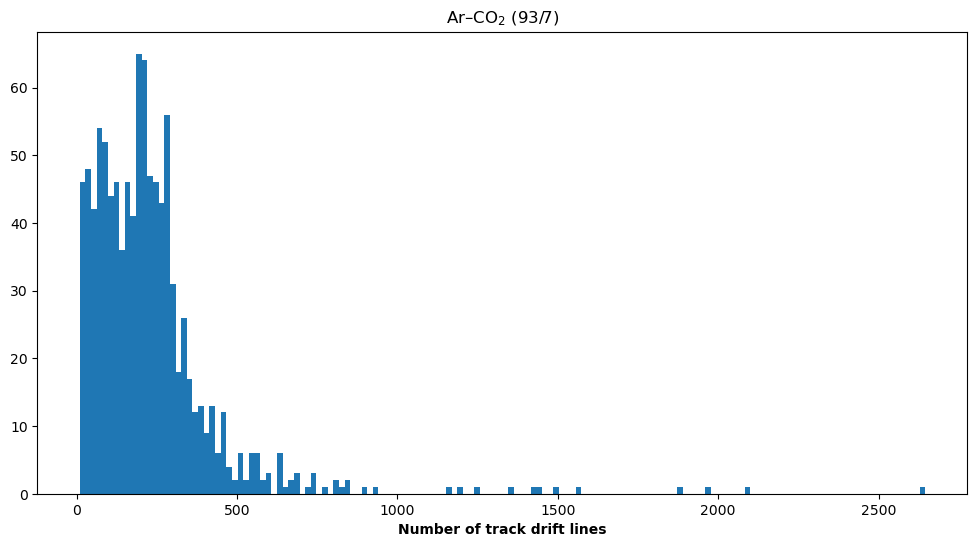

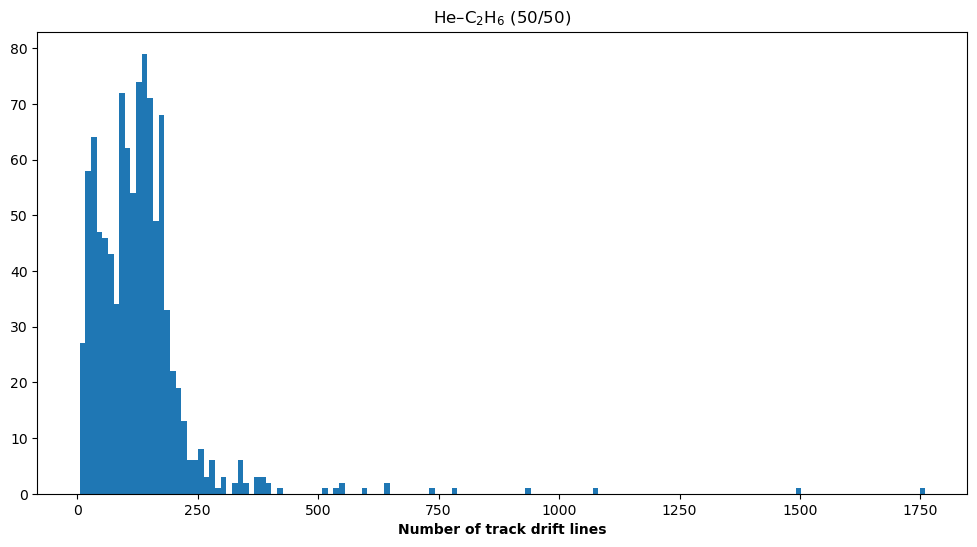

In [15]:
r = 0.71
x, y = get_circle(r, 100, 0)

# Plot histogram of starting positions
def start_pos_hist(df, name):
    fig_a = plt.figure(figsize=(12,6))
    plt.hist(df["num_driftlines"], bins=150)
    plt.xlabel(f"Number of track drift lines", fontweight='bold')
    plt.title(name)

start_pos_hist(Ar_CO2_df, Ar_CO2_str)
start_pos_hist(He_C2H6_df, He_C2H6_str)

10
5


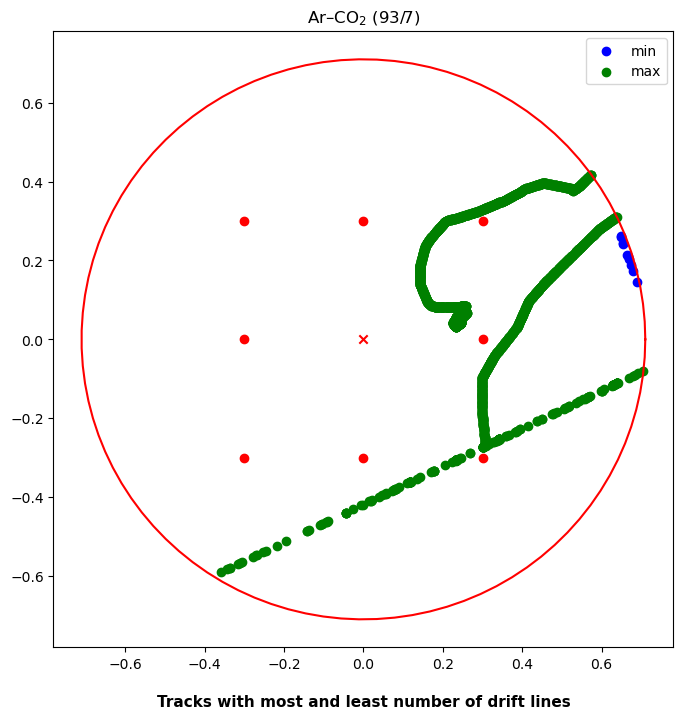

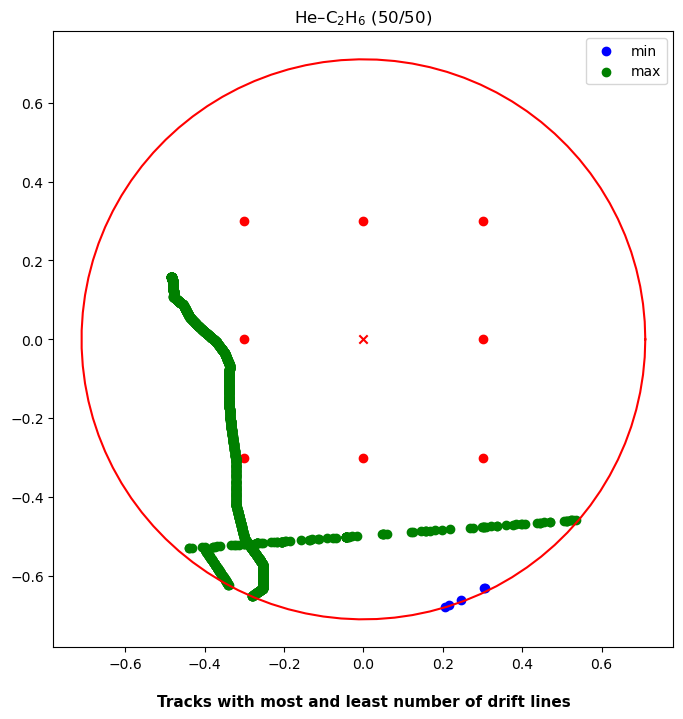

In [16]:
def plot_min_max_tracks(df, name):
    # Plot tracks with highest and lowest amounts of drift lines
    i_min = df["num_driftlines"].idxmin()
    i_max = df["num_driftlines"].idxmax()
    
    fig_c = plt.figure(figsize=(8,8))
    plt.plot(x, y, color="red")
    plt.scatter(0, 0, color="red", marker="x")
    plt.scatter([0.3, -0.3, -0.3, 0.3, 0, 0, -0.3, 0.3], [0.3, 0.3, -0.3, -0.3, 0.3, -0.3, 0, 0], color="red", marker="o")
    plt.xlabel("\nTracks with most and least number of drift lines", fontweight='bold', fontsize=11)
    plt.title(name)
    
    #plot minimum track
    cur_track = df.iloc[i_min]
    datax_i = [float(x) for x in cur_track["line_start_x_split"][:-1]]
    datay_i = [float(x) for x in cur_track["line_start_y_split"][:-1]]
    plt.scatter(datax_i, datay_i, c="blue", label="min")
    print(len(datax_i))
    
    #plot maximum track
    cur_track = df.iloc[i_max]
    datax_i = [float(x) for x in cur_track["line_start_x_split"][:-1]]
    datay_i = [float(x) for x in cur_track["line_start_y_split"][:-1]]
    plt.scatter(datax_i, datay_i, c="green", label="max")
    
    plt.legend()

plot_min_max_tracks(Ar_CO2_df, Ar_CO2_str)
plot_min_max_tracks(He_C2H6_df, He_C2H6_str)

### Drift times

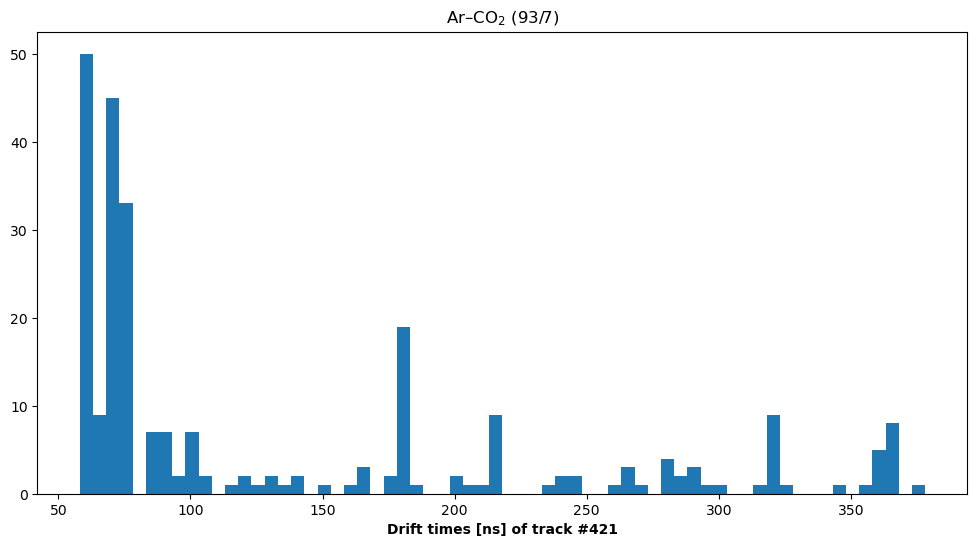

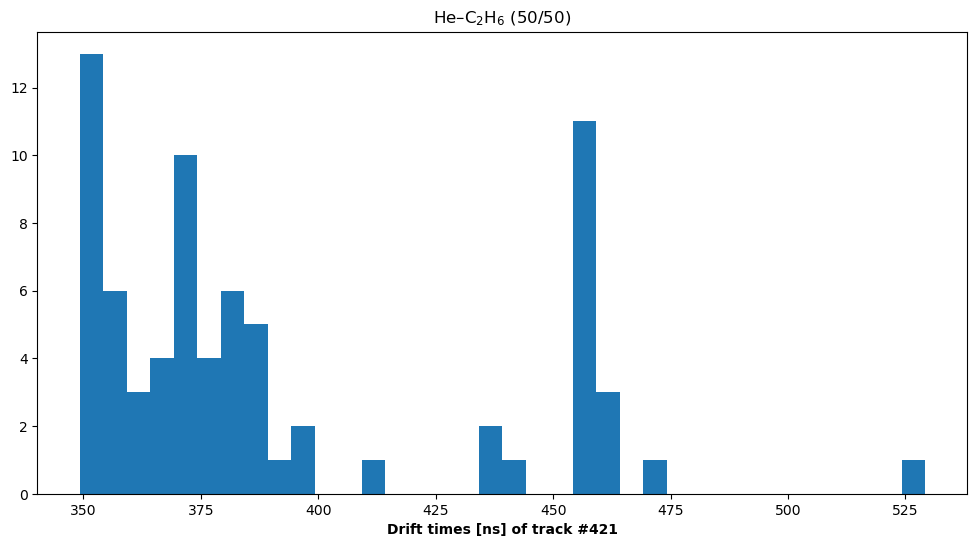

In [18]:
def ran_times_hist(ran_num, df, name):
    width = 5

    ran_track = df.iloc[ran_num]
    data = [float(x) for x in ran_track['drift_times_split'][:-1]]
    bins = np.arange(min(data), max(data) + width, width)
    
    # Plot histogram of drift times
    plt.figure(figsize=(12,6))
    plt.hist(data, bins=bins)
    plt.xlabel(f"Drift times [ns] of track #{ran_num}", fontweight='bold')
    plt.title(name)

ran_num = random.randint(0, len(Ar_CO2_df) - 1)
ran_times_hist(ran_num, Ar_CO2_df, Ar_CO2_str)
ran_times_hist(ran_num, He_C2H6_df, He_C2H6_str)

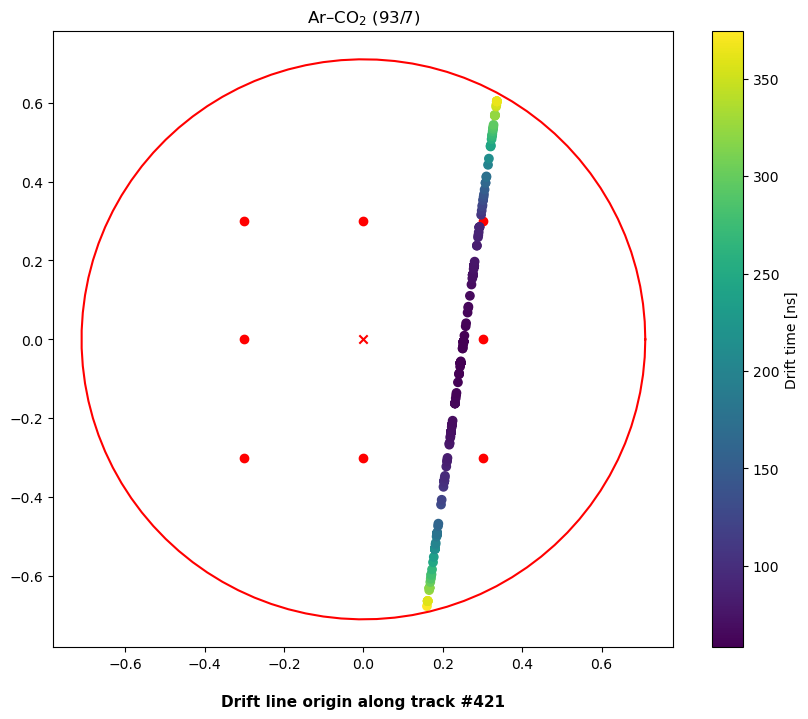

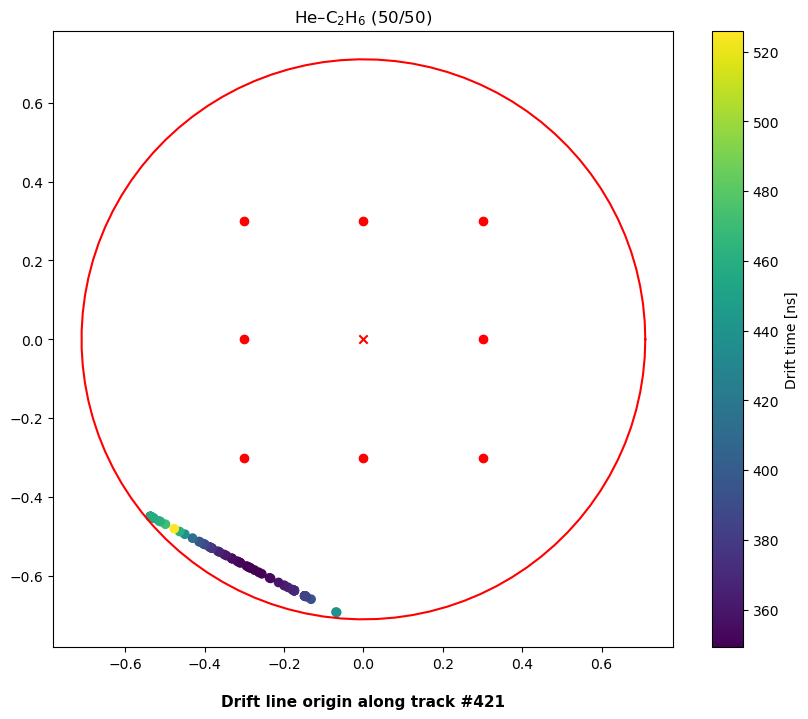

In [19]:
def ran_track_plot(ran_num, df, name):
    # Plot outine of drift tube
    fig_a = plt.figure(figsize=(10,8))
    plt.plot(x, y, color="red")
    plt.scatter(0, 0, color="red", marker="x")
    plt.scatter(xpos[1:], ypos[1:], color="red", marker="o")
    
    # Plot scatter of drift line origins and drift times
    ran_track = df.iloc[ran_num]
    data = [float(x) for x in ran_track['drift_times_split'][:-1]]
    datax = [float(x) for x in ran_track["line_start_x_split"][:-1]]
    datay = [float(x) for x in ran_track["line_start_y_split"][:-1]]
    plt.scatter(datax, datay, c=data, cmap='viridis')
    plt.colorbar(label="Drift time [ns]")
    plt.xlabel(f"\nDrift line origin along track #{ran_num}", fontweight='bold', fontsize=11)
    plt.title(name)

ran_track_plot(ran_num, Ar_CO2_df, Ar_CO2_str)
ran_track_plot(ran_num, He_C2H6_df, He_C2H6_str)

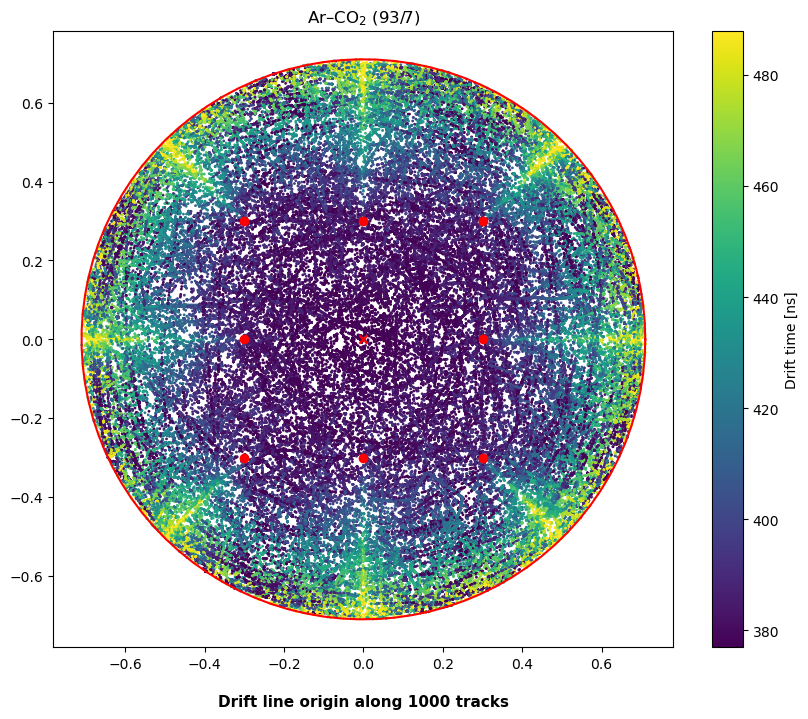

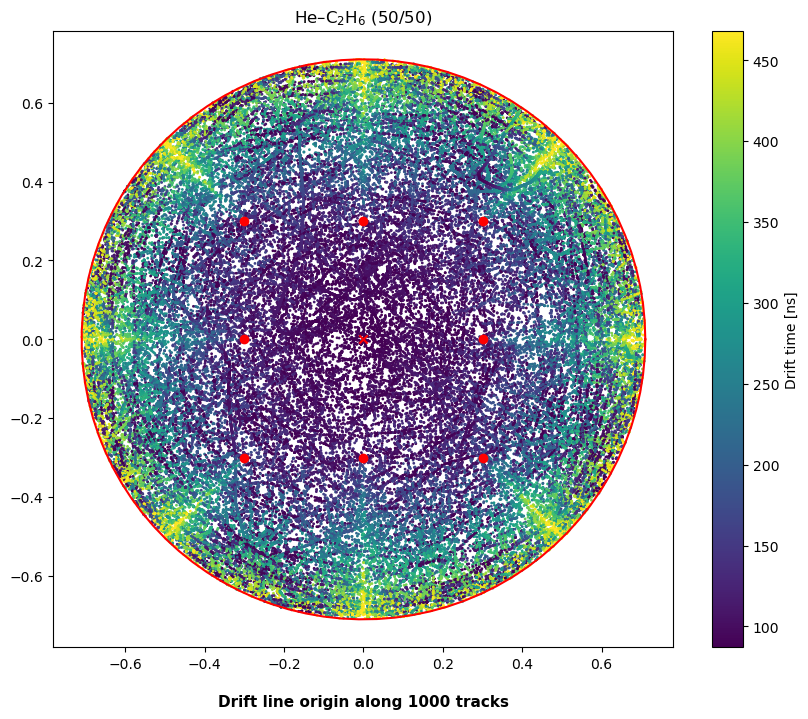

In [20]:
def all_tracks_plot(num_tracks, df, name):
    fig_b = plt.figure(figsize=(10,8))
    
    for i in range(0, num_tracks):
        cur_track = df.iloc[i]
        data_i = [float(x) for x in cur_track['drift_times_split'][:-1]]
        datax_i = [float(x) for x in cur_track["line_start_x_split"][:-1]]
        datay_i = [float(x) for x in cur_track["line_start_y_split"][:-1]]
        plt.scatter(datax_i, datay_i, c=data_i, cmap='viridis', s=1)
    
    plt.colorbar(label="Drift time [ns]")
    plt.xlabel(f"\nDrift line origin along {num_tracks} tracks", fontweight='bold', fontsize=11)
    plt.title(name)
    
    plt.plot(x, y, color="red")
    plt.scatter(0, 0, color="red", marker="x")
    plt.scatter(xpos[1:], ypos[1:], color="red", marker="o")

all_tracks_plot(1000, Ar_CO2_df, Ar_CO2_str)
all_tracks_plot(1000, He_C2H6_df, He_C2H6_str)

## Cell layout

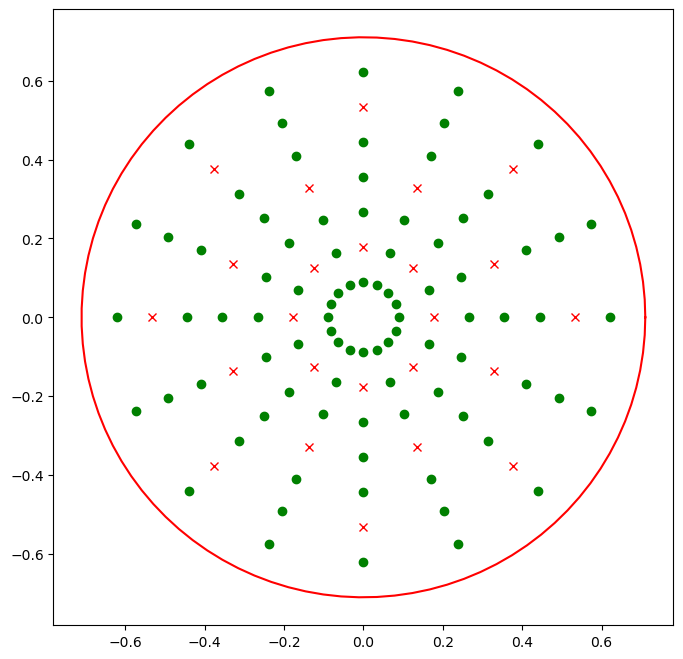

In [132]:
def plot_circular(vis):
    x, y = get_circle(r, 100, 0)

    if vis:
        c = ["green", "red", "red"]
        sy = ["o", "x"]
    else:
        c = ["tab:blue", "orange", "tab:blue"]
        sy = ["o", "o"]

    plt.plot(x, y, color=c[2])
    
    def getx(r, phi): return r*np.cos(phi)
    def gety(r, phi): return r*np.sin(phi)

    all_x = []
    all_y = []
    
    r1 = r/4
    r2 = r/8 
    ring_count = 0
    is_first = True
    
    while r1 < r:
        theta1 = 0
        theta2 = np.pi/8
    
        if is_first:
            is_first = False
            for i in range(0, 16):
                x = getx(r/8, theta1)
                y = gety(r/8, theta1)
                plt.plot(x, y, marker=sy[0], color=c[0])
                theta1 += np.pi/8
                all_x.append(x)
                all_y.append(y)
                
            r2 += r/4
            continue
        
        for i in range(0, 8):
            if not ring_count % 2:
                phi1 = theta1
                phi2 = theta2
            else:
                phi1 = theta2
                phi2 = theta1
    
            theta1 += np.pi/4
            theta2 += np.pi/4

            x = getx(r1, phi1)
            y = gety(r1, phi1)
            plt.plot(x, y, marker=sy[1], color=c[1])
            all_x.append(x)
            all_y.append(y)
    
            xs = [getx(r1, phi2), getx(r2, phi1), getx(r2, phi2)]
            ys = [gety(r1, phi2), gety(r2, phi1), gety(r2, phi2)]
            all_x += xs
            all_y += ys
            plt.scatter(xs, ys, marker=sy[0], color=c[0])
            
        ring_count += 1
        r1 += r/4
        r2 += r/4

    return all_x, all_y

fig_c = plt.figure(figsize=(8,8))
_1, _2 = plot_circular(True)

## Sag and stretch

### Frame setup

In [148]:
def drop_frame(df):
    df['xsag_split'] = df['xsag'].str.split('|')
    df['ysag_split'] = df['ysag'].str.split('|')
    df.drop(columns=['xsag', 'ysag'])

ef_sag_df = pd.read_csv(f'csv/sag/sag_wires_data_ef.csv')
sag_df = pd.read_csv(f'csv/sag/sag_wires_data.csv')
multi_df = pd.read_csv(f'csv/sag/multicell_sag_wires_data.csv')
ef_multi_df = pd.read_csv(f'csv/sag/multicell_sag_wires_data_ef.csv')
circle_sag_df = pd.read_csv(f'csv/sag/circles_sag_data.csv')
ef_circle_sag_df = pd.read_csv(f'csv/sag/circles_sag_data_ef.csv')

half_ef_sag_df = pd.read_csv(f'csv/sag/half_tension/sag_wires_data_ef.csv')
half_sag_df = pd.read_csv(f'csv/sag/half_tension/sag_wires_data.csv')
half_multi_df = pd.read_csv(f'csv/sag/half_tension/multicell_sag_wires_data.csv')
half_ef_multi_df = pd.read_csv(f'csv/sag/half_tension/multicell_sag_wires_data_ef.csv')
half_circle_sag_df = pd.read_csv(f'csv/sag/half_tension/circles_sag_data.csv')
half_ef_circle_sag_df = pd.read_csv(f'csv/sag/half_tension/circles_sag_data_ef.csv')

drop_frame(ef_sag_df)
drop_frame(sag_df)
drop_frame(multi_df)
drop_frame(ef_multi_df)
drop_frame(circle_sag_df)
drop_frame(ef_circle_sag_df)
drop_frame(half_ef_sag_df)
drop_frame(half_sag_df)
drop_frame(half_multi_df)
drop_frame(half_ef_multi_df)
drop_frame(half_circle_sag_df)
drop_frame(half_ef_circle_sag_df)

### Plot sag

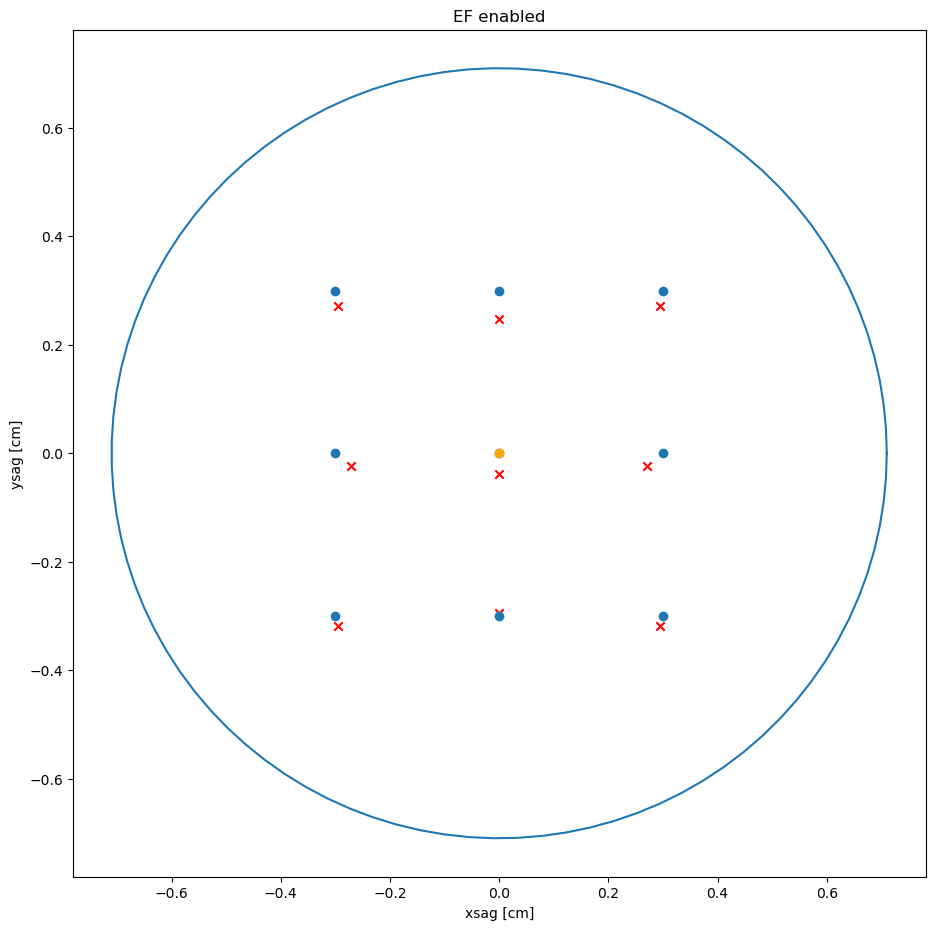

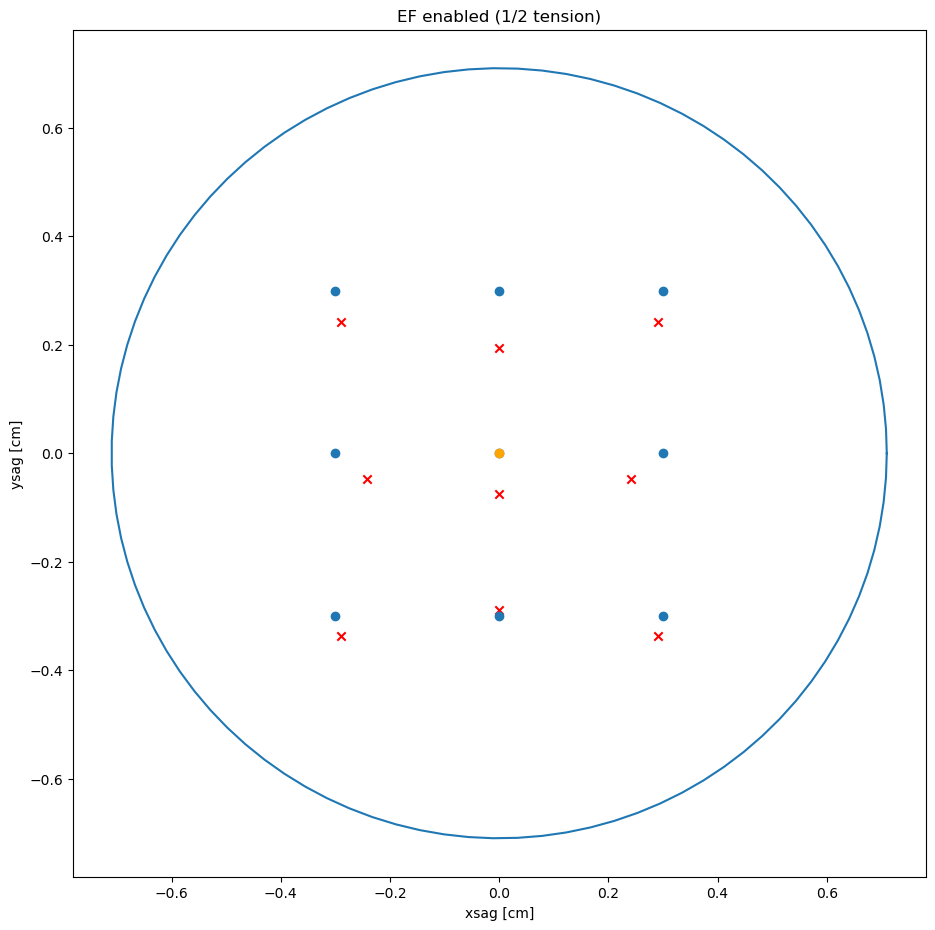

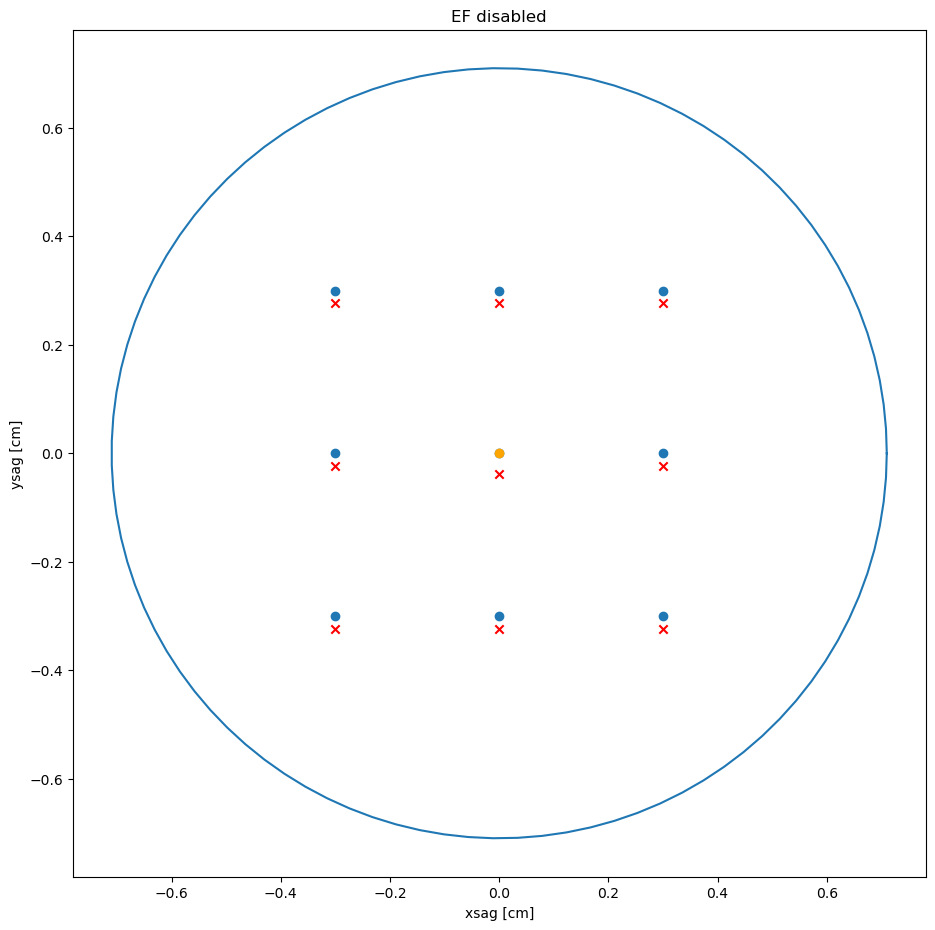

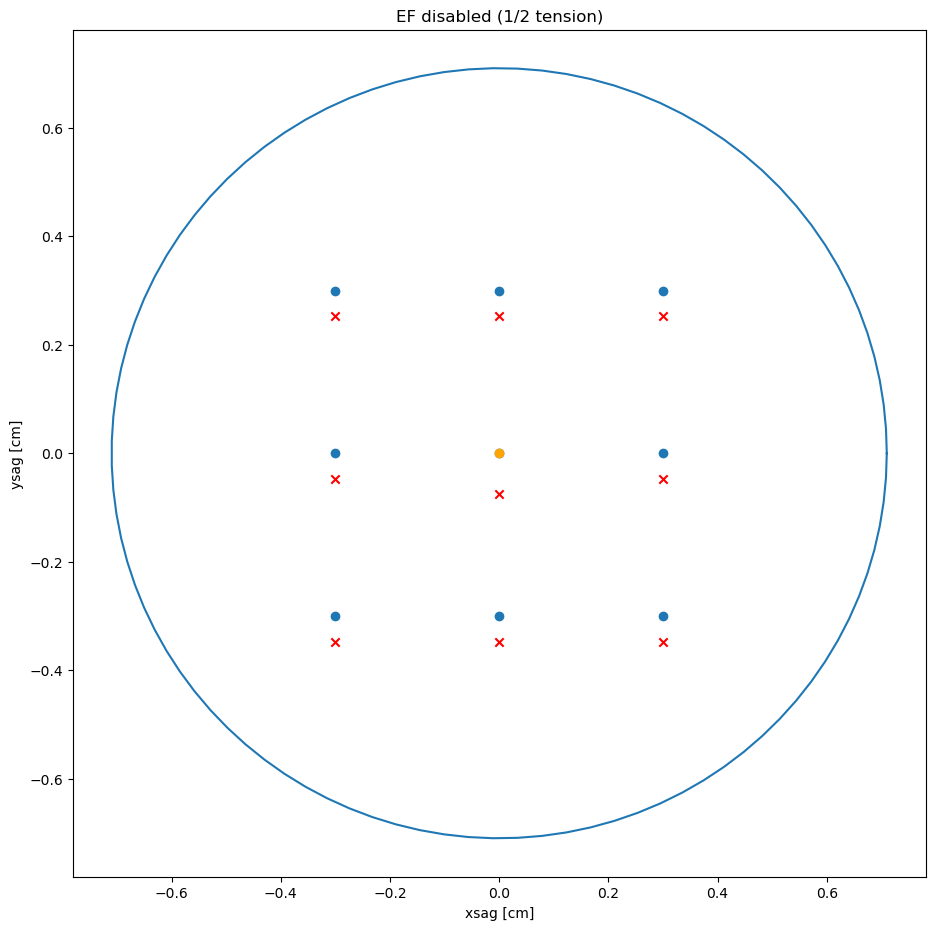

In [150]:
def plot_sag(df, is_ef, is_tension):
    fig_s = plt.figure(figsize=(11,11))
    plt.plot(x, y, color="tab:blue")
    
    for i in range(0,9):
        cur_sag = df.iloc[i]
        datax = np.array([xpos[i]]) + np.array([float(x) for x in cur_sag['xsag_split'][:-1]])
        datay = np.array([ypos[i]]) + np.array([float(x) for x in cur_sag["ysag_split"][:-1]])
        plt.scatter(datax, datay, marker='x', color="red")
        plt.scatter(xpos[i], ypos[i], marker="o", color="tab:blue")

    title_str = ""
    if is_ef:       title_str += "EF enabled"
    else:           title_str += "EF disabled"
    if is_tension:  title_str += " (1/2 tension)"
    plt.title(title_str)

    plt.scatter(0, 0, color="orange")
    plt.xlabel("xsag [cm]")
    plt.ylabel("ysag [cm]")

plot_sag(ef_sag_df, True, False)
plot_sag(half_ef_sag_df, True, True)
plot_sag(sag_df, False, False)
plot_sag(half_sag_df, False, True)

In [152]:
def get_x_y():
    xpos1 = []
    ypos1 = []
    
    cury = 9
    
    for i in range(0, 7):
        curx = 9
        for j in range(0, 7):
            if np.sqrt((curx/10)**2 + (cury/10)**2) < 0.91:
                xpos1.append(curx/10)
                ypos1.append(cury/10)
            curx -= 3
        cury -= 3
    
    return np.array(xpos1), np.array(ypos1)

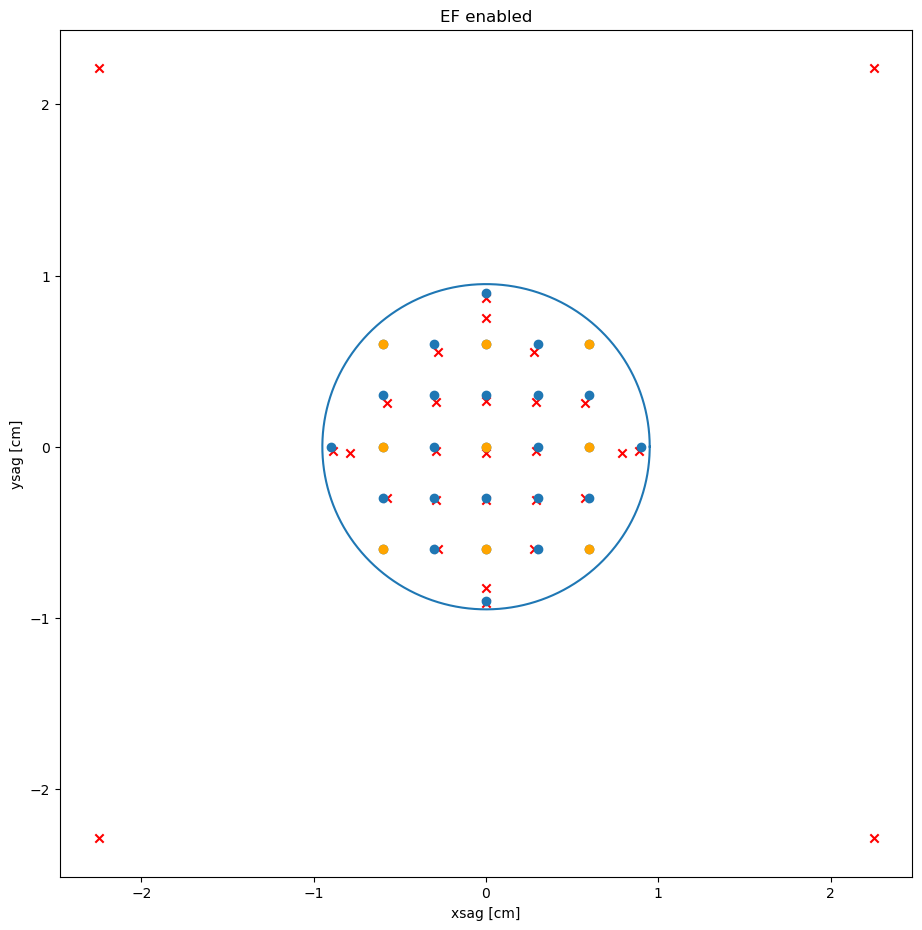

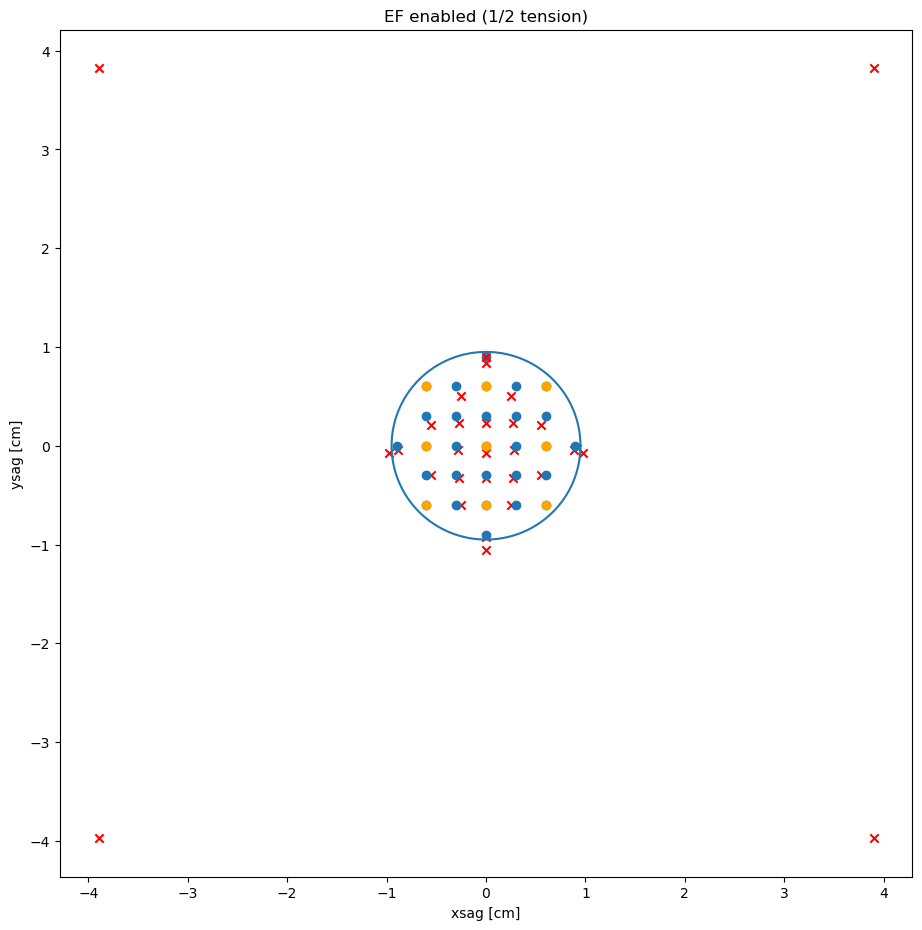

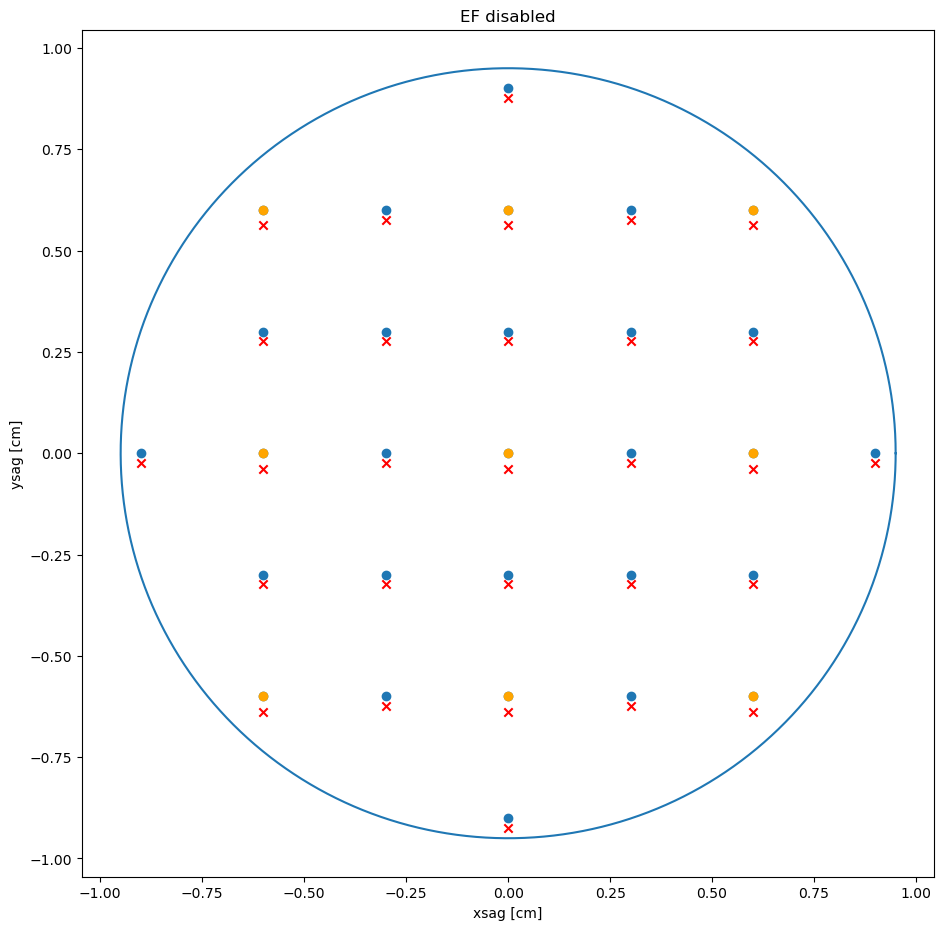

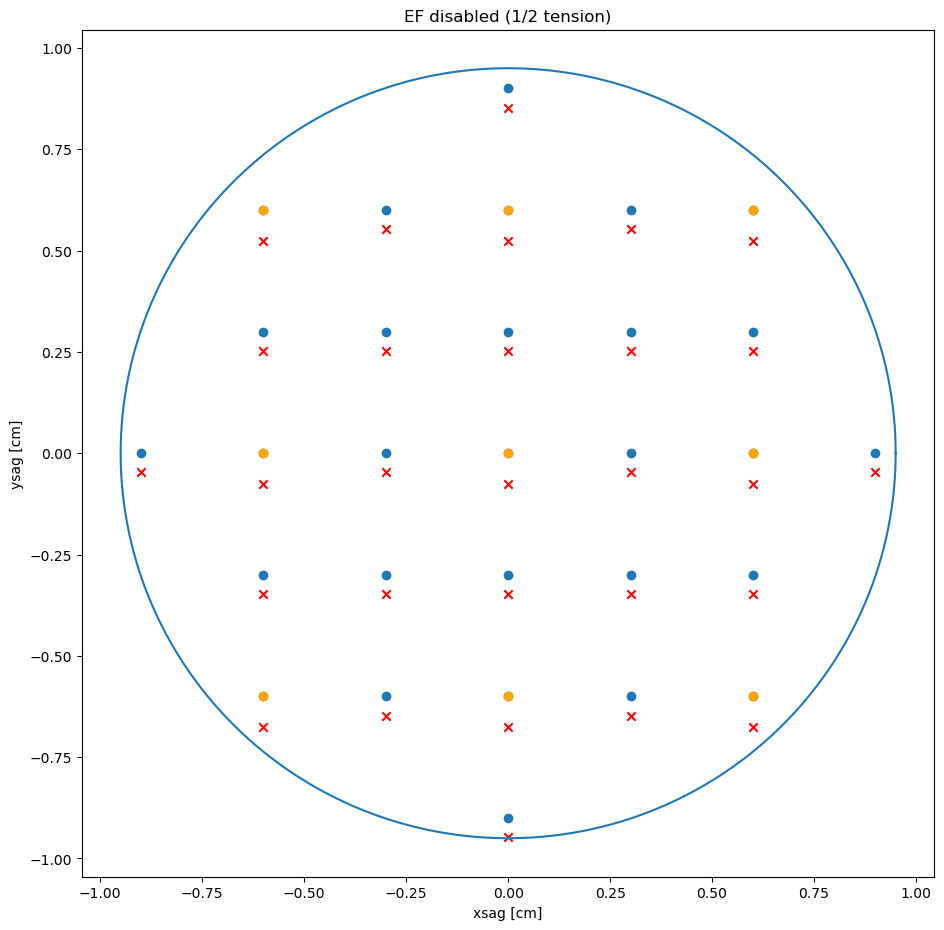

In [154]:
def plot_sag_multicell(df, is_ef, is_tension):
    x, y = get_circle(0.95, 1000, 0)
    fig_s = plt.figure(figsize=(11,11))
    plt.plot(x, y, color="tab:blue")

    xpos1, ypos1 = get_x_y()
    
    for i in range(len(xpos1)):
        cur_sag = df.iloc[i]
        datax = np.array([xpos1[i]]) + np.array([float(x) for x in cur_sag['xsag_split'][:-1]])
        datay = np.array([ypos1[i]]) + np.array([float(x) for x in cur_sag["ysag_split"][:-1]])
        plt.scatter(datax, datay, marker='x', label=cur_sag["wire_label"], color="red")
        plt.scatter(xpos1[i], ypos1[i], marker="o", color="tab:blue")
    
    title_str = ""
    if is_ef:       title_str += "EF enabled"
    else:           title_str += "EF disabled"
    if is_tension:  title_str += " (1/2 tension)"
    plt.title(title_str)
    
    sx = [xpos1[1], xpos1[3], xpos1[5], xpos1[12], xpos1[14], xpos1[16], xpos1[23], xpos1[25], xpos1[27]]
    sy = [ypos1[1], ypos1[3], ypos1[5], ypos1[12], ypos1[14], ypos1[16], ypos1[23], ypos1[25], ypos1[27]]
    plt.scatter(sx, sy, color="orange")
        
    plt.xlabel("xsag [cm]")
    plt.ylabel("ysag [cm]")
    #plt.xlim(-1, 1)
    #plt.ylim(-1, 1)

plot_sag_multicell(ef_multi_df, True, False)
plot_sag_multicell(half_ef_multi_df, True, True)
plot_sag_multicell(multi_df, False, False)
plot_sag_multicell(half_multi_df, False, True)

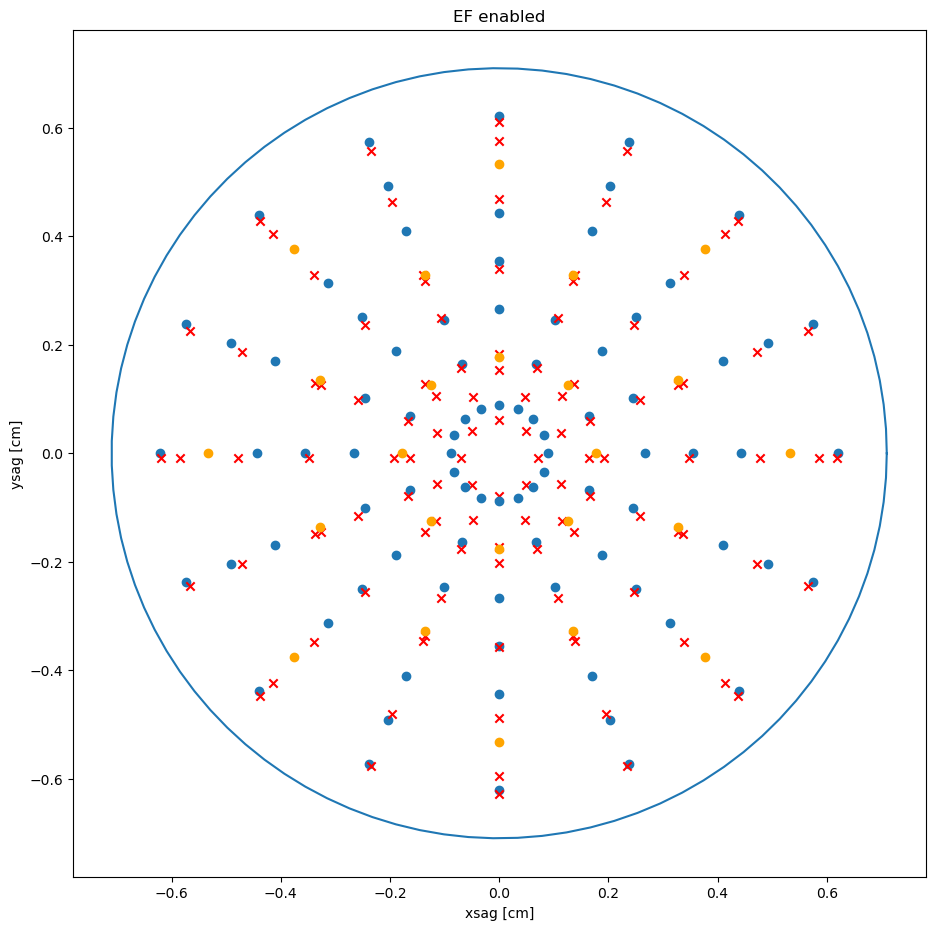

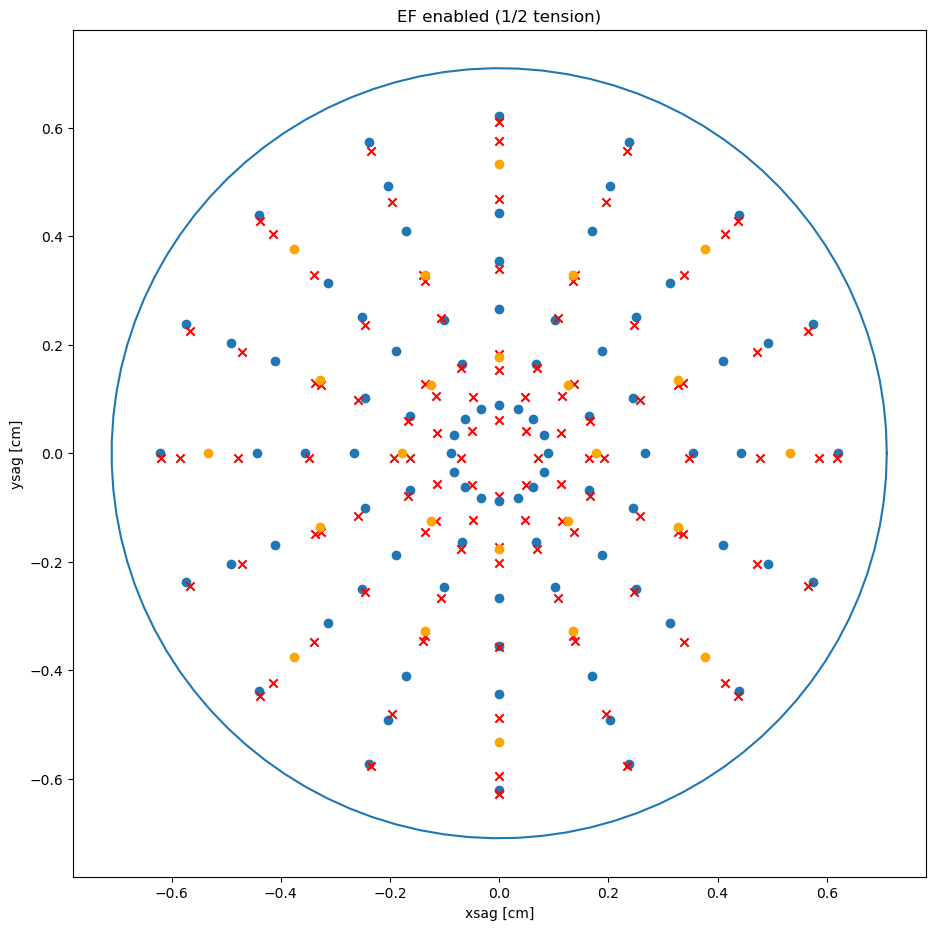

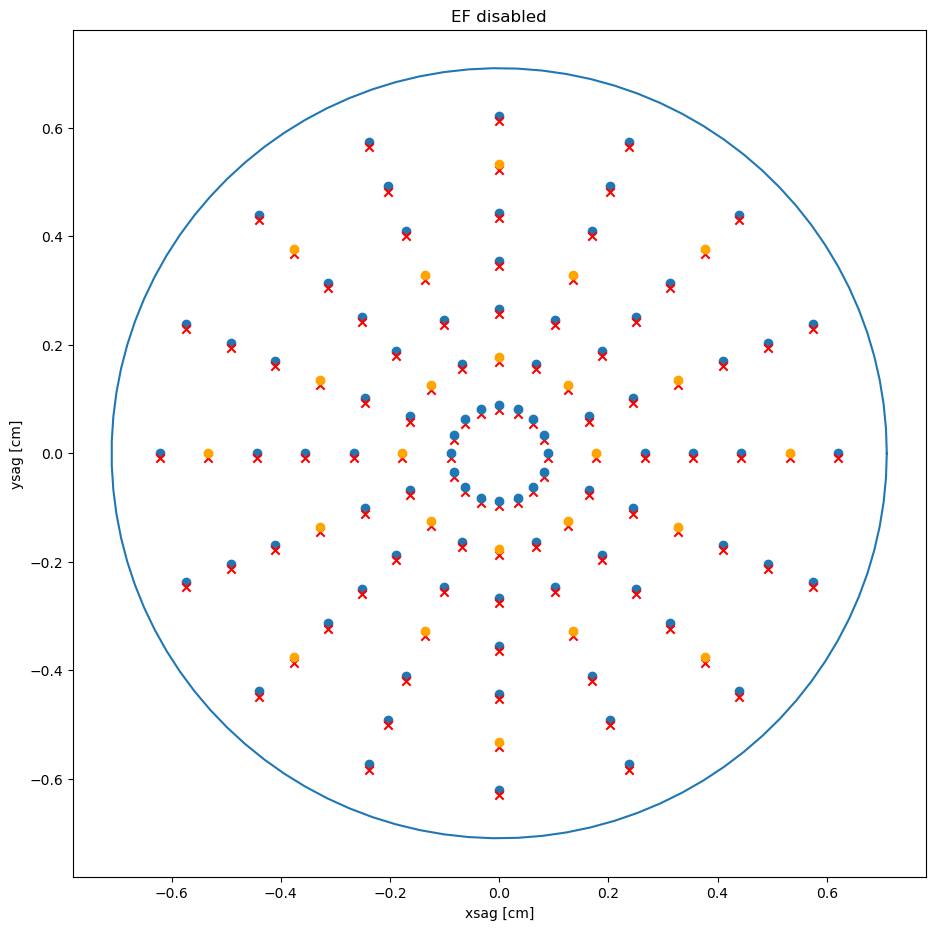

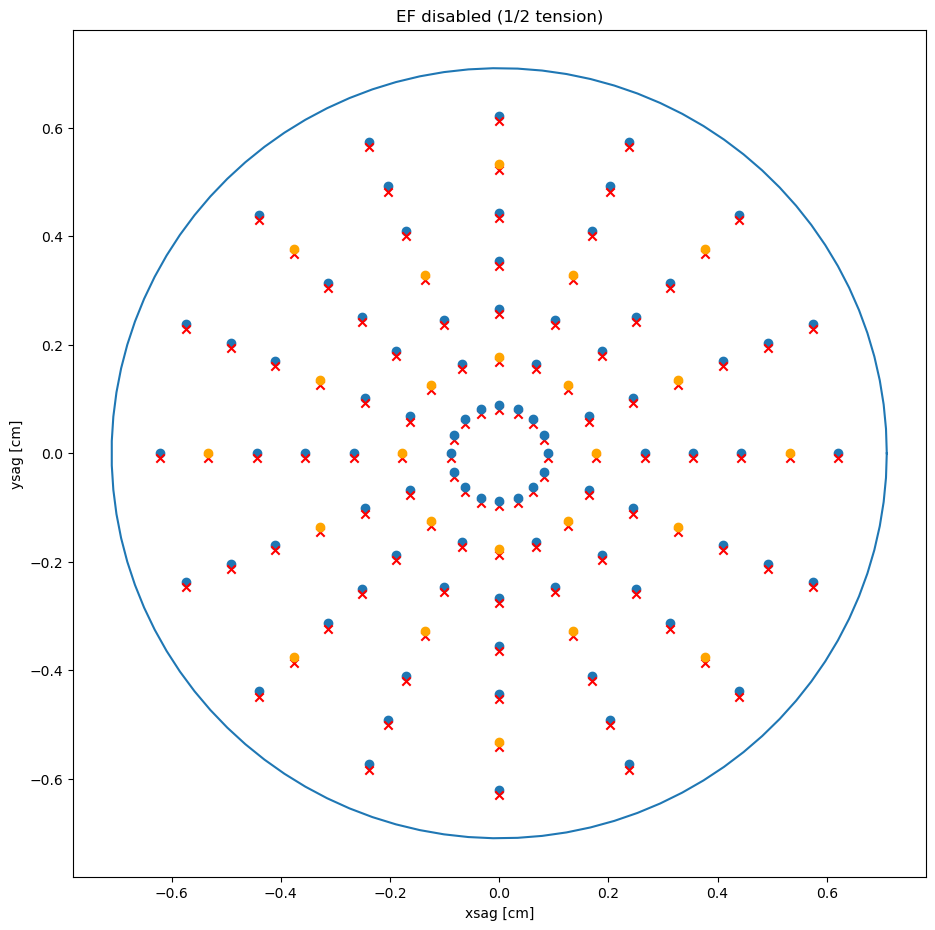

In [155]:
def plot_circle_sag(df, is_ef, is_tension):
    fig_s = plt.figure(figsize=(11,11))
    xpos, ypos = plot_circular(False)
    
    for i in range(0,len(xpos)):
        cur_sag = df.iloc[i]
        datax = np.array([xpos[i]]) + np.array([float(x) for x in cur_sag['xsag_split'][:-1]])
        datay = np.array([ypos[i]]) + np.array([float(x) for x in cur_sag["ysag_split"][:-1]])
        plt.scatter(datax, datay, marker='x', label=cur_sag["wire_label"], color="red")
    
    title_str = ""
    if is_ef:       title_str += "EF enabled"
    else:           title_str += "EF disabled"
    if is_tension:  title_str += " (1/2 tension)"
    plt.title(title_str)
        
    plt.xlabel("xsag [cm]")
    plt.ylabel("ysag [cm]")

plot_circle_sag(ef_circle_sag_df, True, False)
plot_circle_sag(half_ef_circle_sag_df, True, True)
plot_circle_sag(circle_sag_df, False, False)
plot_circle_sag(half_circle_sag_df, False, True)

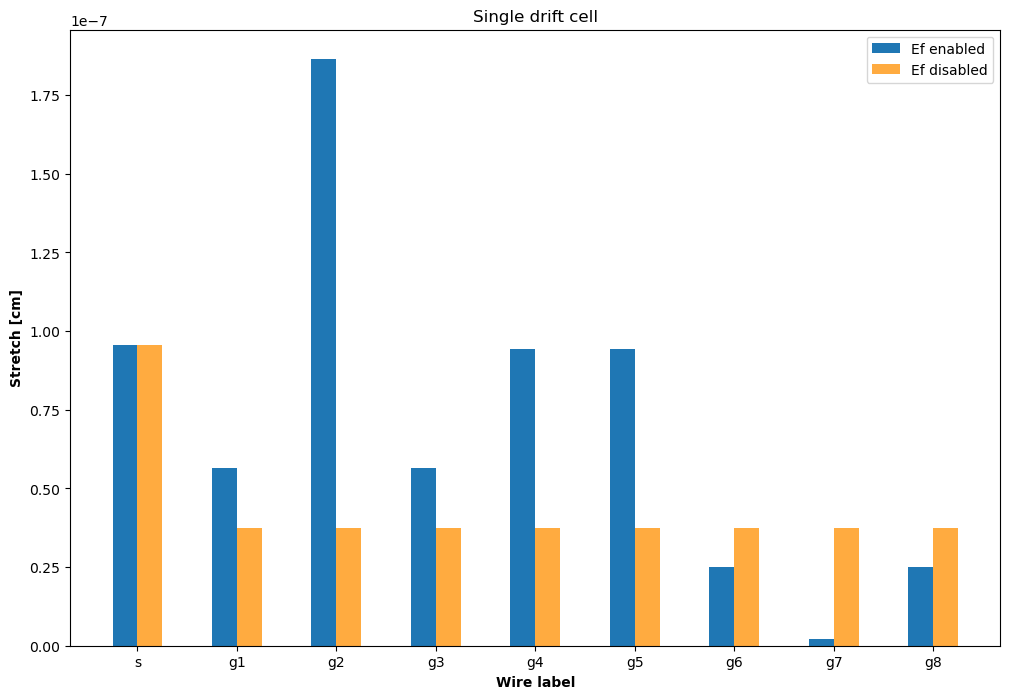

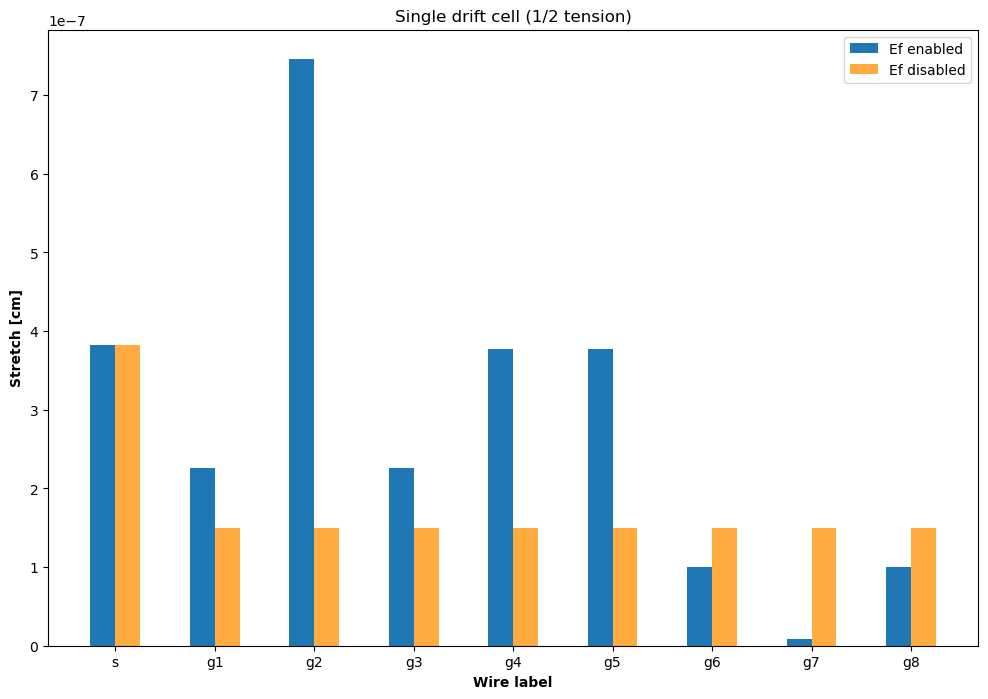

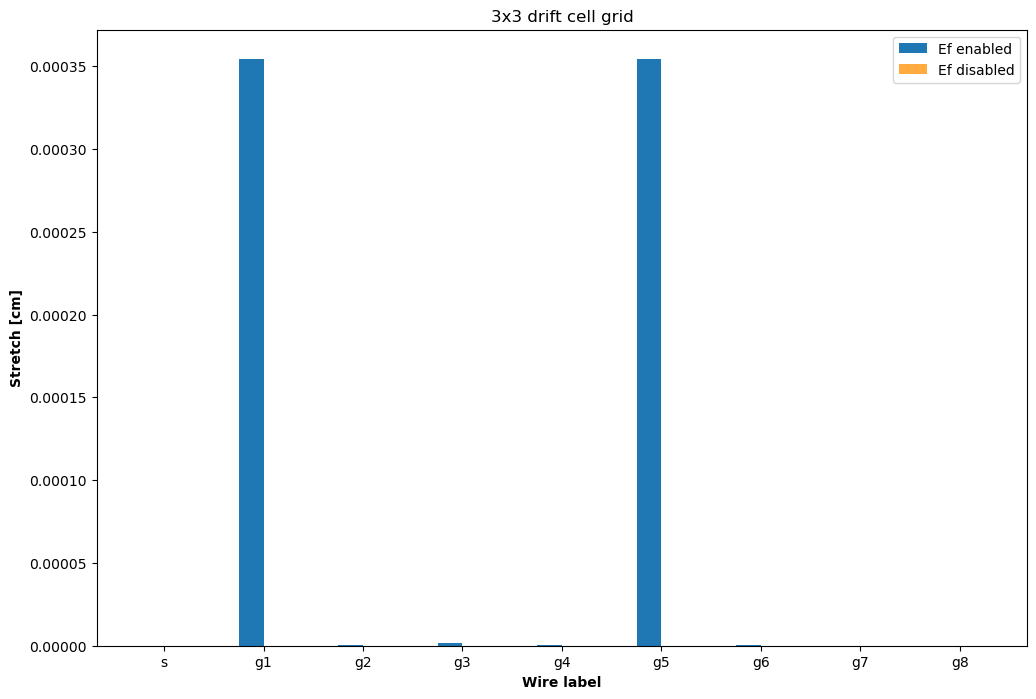

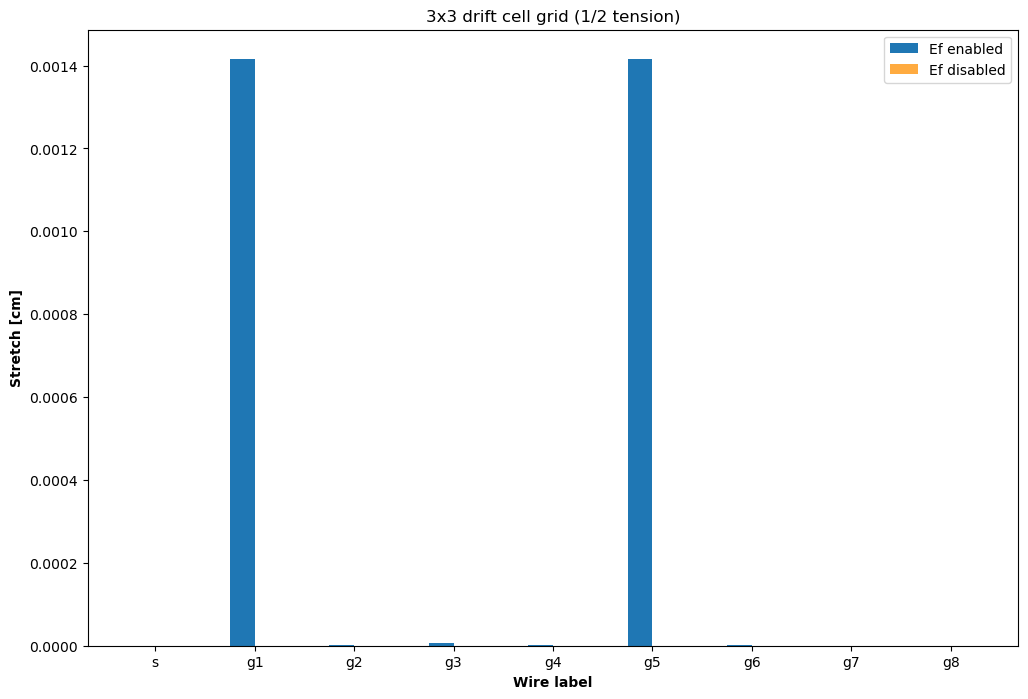

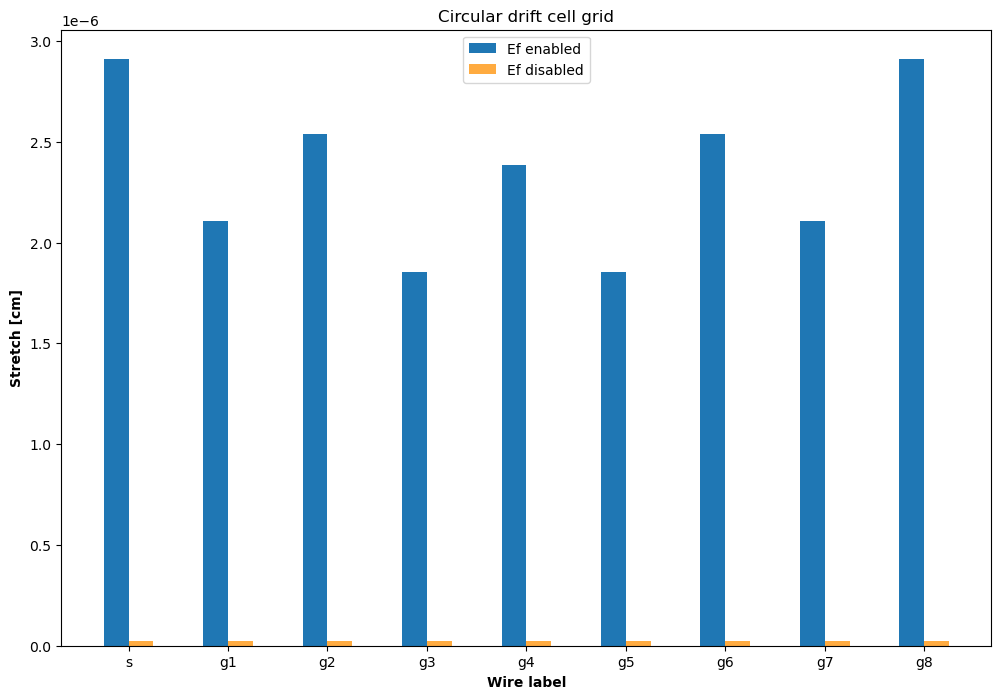

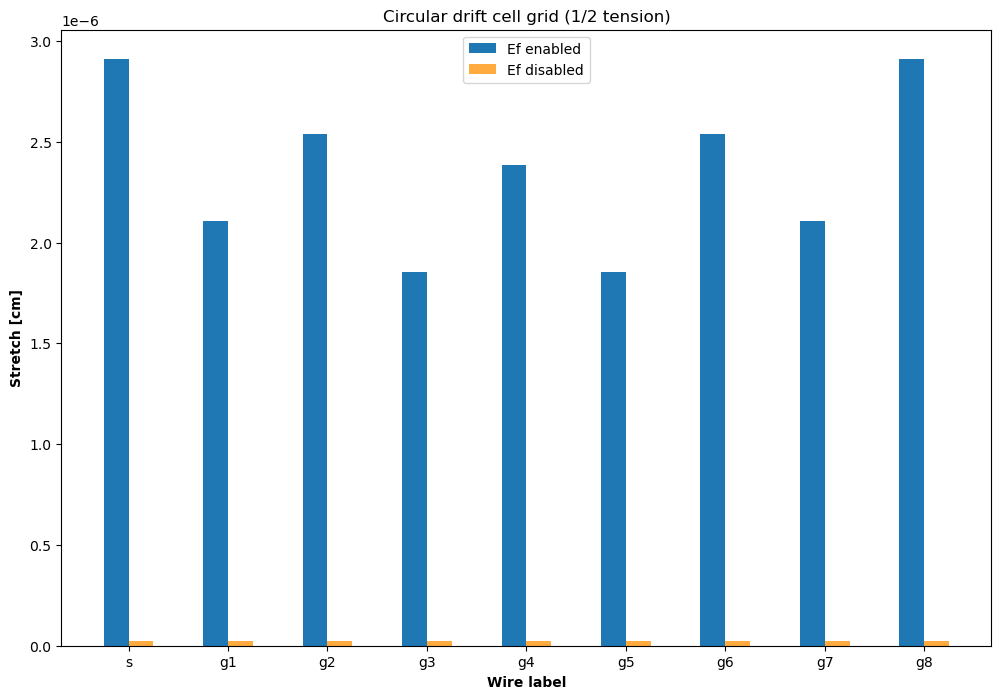

In [160]:
def plot_stretch(ef_df, df, title):
    barWidth = 0.25
    fig = plt.subplots(figsize =(12, 8)) 
    
    noEf_data = []
    ef_data = []
    wire_labels = ["s"]
    
    for i in range(0, 9):
        noEf_data.append(df.iloc[i]["stretch"])
        ef_data.append(ef_df.iloc[i]["stretch"])
        if i: wire_labels.append(f"g{i}")
    
    br1 = np.arange(len(ef_data)) 
    br2 = [x + barWidth for x in br1] 
    br3 = [x + barWidth for x in br2] 
    
    plt.bar(br1, ef_data, label='Ef enabled', width=barWidth) 
    plt.bar(br2, noEf_data, color="#ffab40", width=barWidth, label='Ef disabled') 
    
    plt.xlabel('Wire label', fontweight='bold') 
    plt.ylabel('Stretch [cm]', fontweight='bold') 
    plt.xticks([r + barWidth/2 for r in range(len(ef_data))], wire_labels)
    plt.title(title)
    plt.legend()

plot_stretch(ef_sag_df, sag_df, "Single drift cell")
plot_stretch(half_ef_sag_df, half_sag_df, "Single drift cell (1/2 tension)")
plot_stretch(ef_multi_df, multi_df, "3x3 drift cell grid")
plot_stretch(half_ef_multi_df, half_multi_df, "3x3 drift cell grid (1/2 tension)")
plot_stretch(ef_circle_sag_df, circle_sag_df, "Circular drift cell grid")
plot_stretch(half_ef_circle_sag_df, half_circle_sag_df, "Circular drift cell grid (1/2 tension)")